# 16 多维动态规划

## 16.1 不同路径

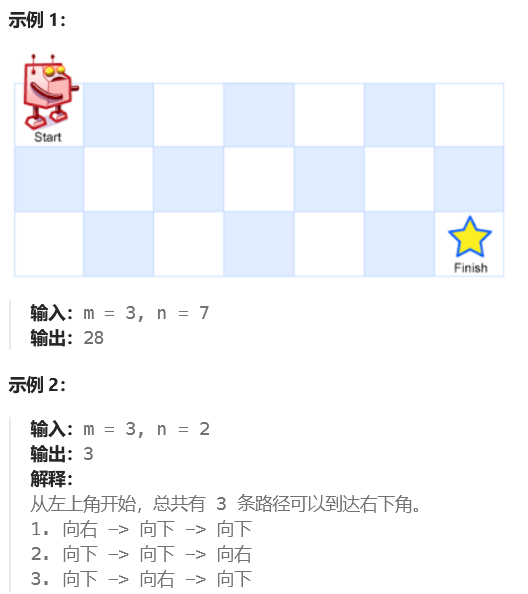

In [ ]:
class Solution:
    def uniquePaths(self, m: int, n: int) -> int:
        # 构建dp数组，初始化为1是因为第一行和第一列只能走一条路径
        dp = [[1]*n for _ in range(m)]
        # 遍历填表
        for i in range(1, m):
            for j in range(1, n):
                dp[i][j] = dp[i-1][j] + dp[i][j-1]
        return dp[-1][-1]

In [ ]:
class Solution:
    def uniquePaths(self, m: int, n: int) -> int:
        dp = [1] * n
        for i in range(1, m):
            for j in range(1, n):
                dp[j] += dp[j-1]
        return dp[-1]
# 二维：
# 1 1 1
# 1 2 3
# 1 3 6

## 16.2 最小路径和

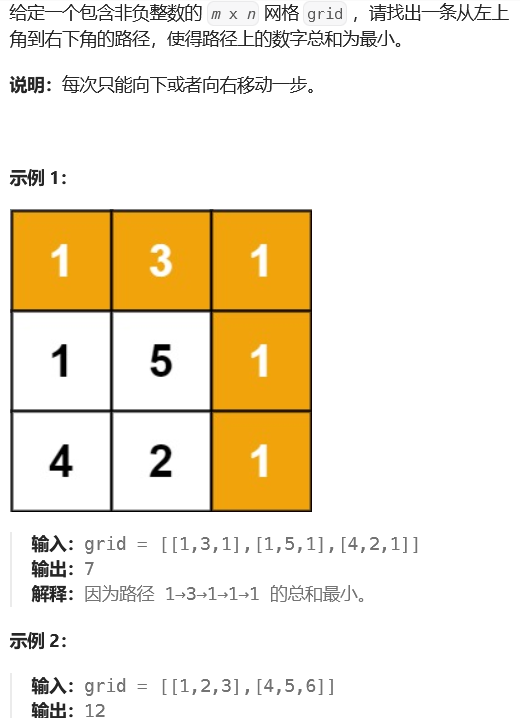

In [ ]:
class Solution:
    def minPathSum(self, grid: List[List[int]]) -> int:
        m = len(grid)
        n = len(grid[0])
        
        # 初始化第一行：只能从左边过来
        for j in range(1, n):
            grid[0][j] += grid[0][j-1]
        
        # 初始化第一列：只能从上边过来
        for i in range(1, m):
            grid[i][0] += grid[i-1][0]
        
        # 填充其余格子
        for i in range(1, m):
            for j in range(1, n):
                grid[i][j] += min(grid[i-1][j], grid[i][j-1])
        return grid[-1][-1]

## 16.3 最长回文子串

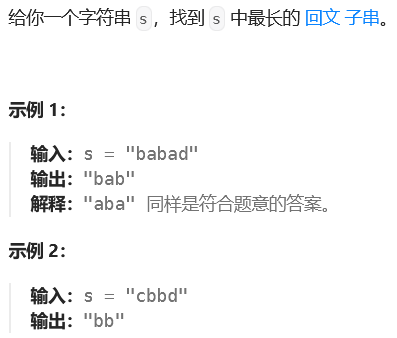

In [ ]:
class Solution:
    def longestPalindrome(self, s: str) -> str:
        def expand(left: int, right: int) -> str:
            # 左右相等就向外扩
            while left >= 0 and right < len(s) and s[left] == s[right]:
                left -= 1
                right += 1
            # 跳出时 [left+1, right-1] 是回文区间
            return s[left+1:right]
        
        res = ""
        for i in range(len(s)):
            # 奇数中心 i
            odd = expand(i, i)
            # 偶数中心 i,i+1
            even = expand(i, i+1)
            # 更新最长
            if len(odd) > len(res):
                res = odd
            if len(even) > len(res):
                res = even
        return res

## 16.4 最长公共子序列

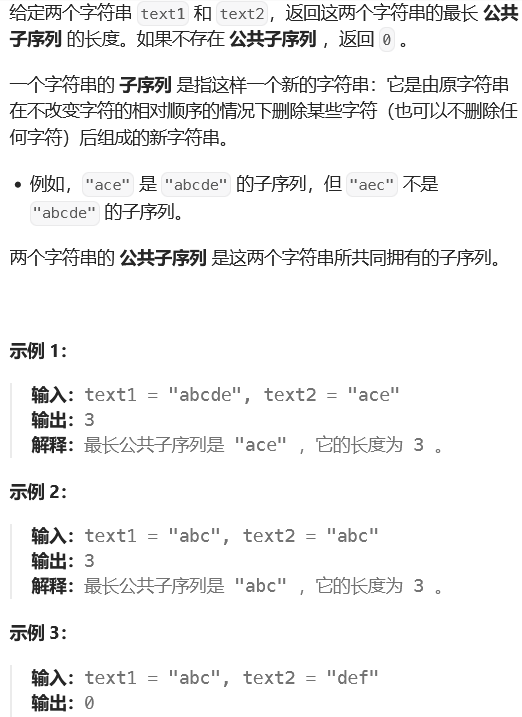

In [ ]:
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:
        # 让text2更短，节省空间
        if len(text1) < len(text2):
            text1, text2 = text2, text1
        m, n = len(text1), len(text2)
        dp = [0]*(n+1)
        
        for i in range(1, m+1):
            prev = 0  # 存dp[i-1][j-1]
            for j in range(1, n+1):
                temp = dp[j]
                if text1[i-1] == text2[j-1]:
                    dp[j] = prev + 1
                else:
                    dp[j] = max(dp[j], dp[j-1])
                prev = temp
        return dp[-1]

In [ ]:
def longestCommonSubsequence(text1: str, text2: str) -> int:
    m, n = len(text1), len(text2)
    # dp大小 (m+1)*(n+1)，首行首列初始0
    dp = [[0]*(n+1) for _ in range(m+1)]
    
    for i in range(1, m+1):
        c1 = text1[i-1]
        for j in range(1, n+1):
            c2 = text2[j-1]
            if c1 == c2:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[m][n]

## 16.5 编辑距离

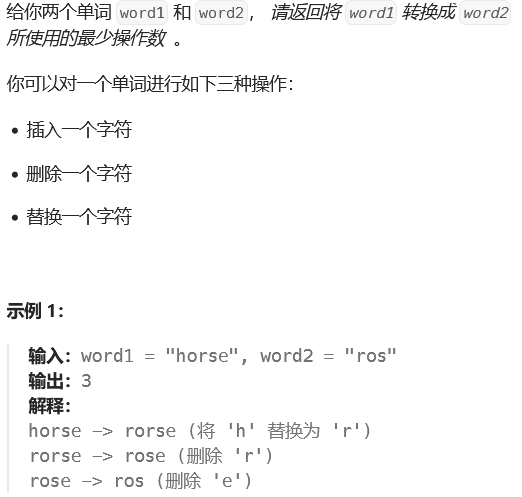

In [ ]:
class Solution:
    def minDistance(self, word1: str, word2: str) -> int:
        m, n = len(word1), len(word2)
        # 创建(m+1)*(n+1) dp表
        dp = [[0]*(n+1) for _ in range(m+1)]
        
        # 初始化边界
        for i in range(m+1):
            dp[i][0] = i
        for j in range(n+1):
            dp[0][j] = j
        
        # 填充dp
        for i in range(1, m+1):
            for j in range(1, n+1):
                if word1[i-1] == word2[j-1]:
                    dp[i][j] = dp[i-1][j-1] # 字符相等，不用操作
                else:
                    dp[i][j] = min(dp[i-1][j-1], dp[i-1][j], dp[i][j-1]) + 1
        return dp[m][n]

In [ ]:
def minDistance(word1: str, word2: str) -> int:
    # 让word2更短，减少数组长度
    if len(word1) < len(word2):
        word1, word2 = word2, word1
    m, n = len(word1), len(word2)
    dp = list(range(n+1))
    
    for i in range(1, m+1):
        prev = dp[0]  # 保存dp[i-1][j-1]
        dp[0] = i
        for j in range(1, n+1):
            temp = dp[j]
            if word1[i-1] == word2[j-1]:
                dp[j] = prev
            else:
                dp[j] = min(prev, dp[j], dp[j-1]) + 1
            prev = temp
    return dp[-1]